In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, f1_score
import os
from sklearn.pipeline import Pipeline
import pickle

In [89]:
pth = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
pth = os.path.abspath(os.path.join(pth, "data/deepseek_augment"))
print(pth)  # Affiche le répertoire parent du répertoire parent

c:\Users\DF6610\Challenge_tech\data\deepseek_augment


In [91]:
df_train = pd.read_csv(pth + "/train.csv")
df_val = pd.read_csv(pth + "/val.csv")
df_test = pd.read_csv(pth + "/test.csv")

In [92]:
label_mapping={'out_of_scope': 0,
 'translate': 1,
 'book_flight': 2,
 'lost_luggage': 3,
 'travel_alert': 4,
 'travel_suggestion': 5,
 'carry_on': 6,
 'book_hotel': 7,
 'flight_status': 8}

In [93]:
X_train= df_train['text']
y_train = df_train['label'].map(label_mapping)

X_val = df_val['text']
y_val = df_val['label'].map(label_mapping)

X_test = df_test['text']
y_test = df_test['label'].map(label_mapping)

In [94]:
df_train_full = pd.concat([df_train, df_val], ignore_index=True)
X_train_full = df_train_full['text']
y_train_full = df_train_full['label'].map(label_mapping)

In [95]:
y_train_full.value_counts()

label
0    242
6    111
3    100
7     88
2     82
1     81
8     74
5     66
4     47
Name: count, dtype: int64

In [96]:
frequencies = dict(y_train_full.value_counts())
# Total des échantillons
total_samples = sum(frequencies.values())
# Calcul des poids inversés
weights = {key: total_samples / (freq * len(frequencies)) for key, freq in frequencies.items()}
# Appliquer un facteur de 2 à la classe 3 pour augmenter son poids
weights[3] *= 2
weights

{0: np.float64(0.4090909090909091),
 6: np.float64(0.8918918918918919),
 3: np.float64(1.98),
 7: np.float64(1.125),
 2: np.float64(1.2073170731707317),
 1: np.float64(1.2222222222222223),
 8: np.float64(1.337837837837838),
 5: np.float64(1.5),
 4: np.float64(2.106382978723404)}

In [98]:
n = 200 # Nombre de features à conserver
# Initialiser le vectoriseur TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=n)

# Apprendre le vocabulaire et transformer les textes
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_val_tfidf = tfidf_vectorizer.transform(X_val)

In [100]:
# Initialiser et entraîner le modèle SVM
# Dictionnaire des poids de classes
class_weights = weights
svm_model = SVC(kernel='linear', random_state=42, class_weight=class_weights)
svm_model.fit(X_train_tfidf, y_train)

SVC(class_weight={0: np.float64(0.4090909090909091),
                  1: np.float64(1.2222222222222223),
                  2: np.float64(1.2073170731707317), 3: np.float64(1.98),
                  4: np.float64(2.106382978723404), 5: np.float64(1.5),
                  6: np.float64(0.8918918918918919), 7: np.float64(1.125),
                  8: np.float64(1.337837837837838)},
    kernel='linear', random_state=42)

In [101]:
# Prédire sur l'ensemble de test
y_val_pred = svm_model.predict(X_val_tfidf)

# Afficher les résultats de classification
print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

           0       0.63      0.79      0.70        24
           1       0.78      0.64      0.70        11
           2       0.67      0.22      0.33         9
           3       0.41      0.64      0.50        11
           4       0.00      0.00      0.00         1
           5       0.00      0.00      0.00         1
           6       1.00      0.78      0.88         9
           7       0.64      0.64      0.64        11
           8       0.83      0.45      0.59        11

    accuracy                           0.61        88
   macro avg       0.55      0.46      0.48        88
weighted avg       0.68      0.61      0.62        88



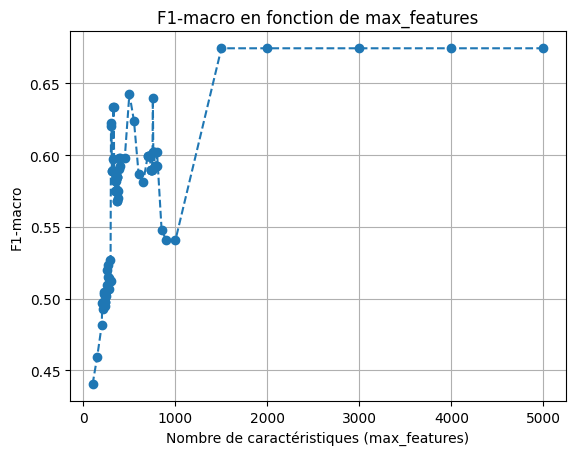

Meilleur nombre de caractéristiques (max_features) : 1500
Meilleur F1-macro score : 0.6745281737501417


In [105]:


# Paramètres à tester avec GridSearch
param_grid = {
    
    'max_features': [100,150,200, 205, 210, 215, 220, 225, 230, 235, 240, 245, 250, 255, 260, 265, 270, 275, 280, 285, 290, 295, 300, 305, 310, 315, 320, 325, 330, 335, 340, 345, 350, 355,356,357,358,359 ,360,361,362,363,364 ,365, 370, 375, 380, 385, 390, 395, 400,450,500,550,600,650,700, 705, 710, 715, 720, 725, 730, 735, 740, 745, 750, 755, 760, 765, 770, 775, 780, 785, 790, 795, 800,850,900,1000,1500,2000,3000,4000,5000]  # Différentes valeurs de n pour le TF-IDF
}


# Listes pour stocker les résultats
f1_scores = []
max_features_values = []

# Parcourir les différents paramètres de GridSearch
for max_feat in param_grid['max_features']:
    # Initialiser le vectoriseur TF-IDF avec un nombre de features (max_features)
    tfidf_vectorizer = TfidfVectorizer(max_features=max_feat)

    # Apprendre le vocabulaire et transformer les textes
    X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
    X_val_tfidf = tfidf_vectorizer.transform(X_val)

    # Initialiser et entraîner le modèle SVM avec les poids de classe
    svm_model = SVC(kernel='linear', random_state=42, class_weight=class_weights)
    svm_model.fit(X_train_tfidf, y_train)

    # Prédictions sur l'ensemble de validation
    y_val_pred = svm_model.predict(X_val_tfidf)

    # Calculer la F1-macro score
    f1 = f1_score(y_val, y_val_pred, average='macro')
    
    # Ajouter les résultats à nos listes
    f1_scores.append(f1)
    max_features_values.append(max_feat)

# Tracer les F1-scores en fonction de max_features
plt.plot(max_features_values, f1_scores, marker='o', linestyle='--')
plt.xlabel('Nombre de caractéristiques (max_features)')
plt.ylabel('F1-macro')
plt.title('F1-macro en fonction de max_features')
plt.grid(True)
plt.show()

# Résultats finaux
best_max_features = max_features_values[f1_scores.index(max(f1_scores))]
print(f"Meilleur nombre de caractéristiques (max_features) : {best_max_features}")
print(f"Meilleur F1-macro score : {max(f1_scores)}")


In [106]:
n= 1500
# Créer la pipeline
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=n)),  # Vectorisation TF-IDF
    ('svm', SVC(kernel='linear', random_state=42, class_weight=class_weights))  # Modèle SVM
])

# Entraîner la pipeline sur les données
pipeline.fit(X_train_full, y_train_full)

Pipeline(steps=[('tfidf', TfidfVectorizer(max_features=1500)),
                ('svm',
                 SVC(class_weight={0: np.float64(0.4090909090909091),
                                   1: np.float64(1.2222222222222223),
                                   2: np.float64(1.2073170731707317),
                                   3: np.float64(1.98),
                                   4: np.float64(2.106382978723404),
                                   5: np.float64(1.5),
                                   6: np.float64(0.8918918918918919),
                                   7: np.float64(1.125),
                                   8: np.float64(1.337837837837838)},
                     kernel='linear', random_state=42))])

In [107]:
# Prédire sur l'ensemble de test
y_test_pred = pipeline.predict(X_test)
# Afficher les résultats de classification
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.71      1.00      0.83        30
           1       1.00      0.90      0.95        10
           2       0.83      1.00      0.91        10
           3       1.00      0.80      0.89        10
           4       1.00      0.80      0.89        10
           5       1.00      0.40      0.57        10
           6       1.00      1.00      1.00        10
           7       1.00      0.80      0.89        10
           8       1.00      0.90      0.95        10

    accuracy                           0.87       110
   macro avg       0.95      0.84      0.88       110
weighted avg       0.91      0.87      0.87       110

